# Continuous-Time Gaussian-Process Trajectory Estimation on SE(3) with a White Noise on Acceleration Prior

In robotic state estimation, we almost always use discrete elements to represent a continuous robot trajectory. However, there are several situations in which we would like to be able to *query* a continuous representation of the robot's trajectory at arbitrary times. A continuous representation allows us to
- **Sample the trajectory at arbitrary times**: In downstream processes like control, planning, or mapping, we may want higher temporal fidelity on our estimated trajectory than is available from the measurements or estimated states.
- **Handle high-rate or asynchronous measurements**: Estimation takes place in regular time intervals, but many sensors are not available at the same interval or are available at much higher rates than can be supported by the estimation regime. 
- **Overcome observability issues**: Sweeping-while-moving sensors such as rolling-shutter cameras or spinning lidars, the trajectory is often under-constrained by the measurements alone since each pixel or point is acquired from a unique pose.
- **Impose continuous-time smoothness constraints**: Particular choices of continuous-time motion priors can regularize and smooth the representation.

In this notebook, we consider a form of continuous-time (CT) estimation that represents the estimated trajectory with a Gaussian process (GP). Though the representation is continuous, the estimation itself uses discrete variables. This notebook introduces a set of tools that have been introduced to GTSAM to allow us to perform this form of estimation on $SE(3)$. We use a simple trajectory example that is based on example in Figure 5.3 of our paper, [Smoothing Out the Edges: Continuous-Time Estimation with Gaussian Process Motion Priors on Factor Graphs](https://arxiv.org/abs/2605.09073). The functions shown here are based on the GTSAM additions that were developed as part of the contributions of this paper. Please see the paper for additional details on the math underlying continuous-time GP estimation on factor graphs.

We use the GTSAM framework to show how to:
- Add a continuous-time motion prior to smooth a trajectory and endow the estimation solution with a continuous-time GP interpretation
- Use GP interpolation to sample the trajectory at arbitrary times
- Add measurements to the factor graph at times that do not explicitly correspond to the optimized estimation states
- Convert a standard factor graph into an equivalent graph with some of its states interpolated (and thus removed from the optimization)

Currently, the framework supports interpolation on the following types:
- `Point1`
- `Point2`
- `Point3`
- `Pose2`
- `Pose3`
Our example is defined on the `Pose3` class.

> **Warning**: This notebook requires `pyvista` to be installed in the user's environment to run the plotting properly.

Author: Connor Holmes

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/gtsam/python/gtsam/examples/GaussianProcessWnoaInterpolationSE3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GTSAM Copyright 2010-2022, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [52]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
    %pip install --quiet pyvista

except ImportError:
    pass

In [53]:
import gtsam
import numpy as np
from typing import List

from gtsam import Pose3, StateData
from gtsam.symbol_shorthand import X, V

# Plotting tools
from GaussianProcessWnoaInterpolationSE3Helpers import collect_estimated_plot_data, collect_interp_plot_data, plot_results

## Setup and Ground Truth

We start by defining the ground-truth values for the trajectory that we wish to estimate. To start, we will use `K+1` estimated states (`K` intervals), but we will use interpolation to upsample the ground-truth trajectory at a higher rate of `K_sample`. 

We separate the ground-truth trajectory into two GTSAM `Values` objects: one for the states at the estimation rate (`K+1` states) and one for the states at the interpolation rate (`K_sample*K+1` states). 

In [54]:

# Number of intervals
K = 7 
# Interpolation upsampling rate
K_sample = 5
# Time interval of trajectory
tmax = 10 

# Seed  (for reproducibility)
np.random.seed(42)

# number of intervals
K_all = K_sample*K
# all times  (including interpolation)
times_all = np.linspace(0, tmax, K_all+1)

# Loop through all times (including interpolated times) to compute the ground-truth trajectory
values_gt = gtsam.Values()
for k in range(K_all+1):
    # Define 6dof GT velocity and add to values
    velocity = np.array([0, 0, -0.3*np.sin(2*np.pi*times_all[k]/tmax), -1, 0, 0]).reshape(6,1)
    # Add pose to values
    if k == 0:
        pose = Pose3.Expmap(np.zeros(6))
    else:
        delta_t = (times_all[k]-times_all[k-1])
        rel_pose = Pose3.Expmap(velocity*delta_t)
        pose = rel_pose.compose(pose)
    # Non-interpolated values for estimation
    values_gt.insert(X(k), pose)
    values_gt.insert(V(k), velocity)
    



## Defining the States

To perform our estimation, need a way to keep track of which pose and velocity keys correspond to a given time `t`. To do so, we make use of the `StateData` class, which links poses, velocities, and times for a given state.


In [55]:
est_states: List[StateData] = []
for k in range(K_all+1):
    state_data = StateData(X(k), V(k), times_all[k])
    if k % K_sample == 0:
        est_states.append(state_data)

## Defining the Factor Graph

We now define a simple factor graph with unary factors on the estimated states. Crucially, we also introduce a motion prior factor that will endow the solution with the continuous-time interpretation: the white-noise-on-acceleration (WNOA) motion prior, `WnoaMotionPrior`.

This prior is defined between consecutive states in the continuous-time trajectory. When defining the WNOA motion factors, we need specify:
- two `StateData` objects that correspond to the two states that the factor connects, which allow the factor to perform interpolation at the correct times when evaluating the error and Jacobians.
- a power spectral density matrix diagonal `Qc` that defines the smoothness properties of the prior. 

In [56]:
# Measurement covariance and noise model
R_meas = 1e-2*np.diag([0.1, 0.1, 0.1, 1, 1, 1])
noise_model = gtsam.noiseModel.Gaussian.Covariance(R_meas)
# Power Spectral Density Matrix for the GP Prior (diagonal-only)
Qc = 0.008*np.array([0.1, 0.1, 0.1, 1, 1, 1])

# Create a graph for the estimated states
graph = gtsam.NonlinearFactorGraph()
# Add factors
meas_poses = []
for k in range(K+1):
    # Get the current state
    curr_state: StateData = est_states[k]
    # Get measurement perturbation due to noise
    xi_pert = np.sqrt(R_meas)@np.random.randn(6,1)
    xi_pert = np.vstack([xi_pert[3:,:], xi_pert[:3,:]]) # Consistent with paper plot
    pose_pert = gtsam.Pose3.Expmap(xi_pert)
    pose_meas = pose_pert.compose(values_gt.atPose3(curr_state.pose))
    meas_poses.append(pose_meas) # Keep track for plotting
    
    # Add measurement
    graph.addPriorPose3(curr_state.pose, pose_meas,noise_model)
    
    # Add WNOA Motion Factor
    if k>0:
        prev_state = est_states[k-1]
        graph.add(gtsam.WnoaMotionFactorPose3(prev_state, curr_state, Qc))  

## Optimization

We are ready to optimize! We generate an initial guess for the trajectory by starting at the ground-truth initial pose and then rolling out the trajectory mean using the initial twist `varpi_0`. Note that we only define initial values for the estimated states (the interpolated states are not defined in the factor graph). After optimization, we can evaluate the results by comparing the estimated trajectory to the ground-truth trajectory. 

In [57]:
# Define the constant velocity estimate (not equal to GT)
varpi_0 = np.array([0, 0, 0,-1.0, 0, 0]).reshape(6,1)
# Generate the initial trajectory values at the estimation rate
values_init = gtsam.Values()

# Start from the ground-truth initial pose
pose_init = values_gt.atPose3(est_states[0].pose)
values_init.insert(est_states[0].pose, pose_init)
values_init.insert(est_states[0].velocity, varpi_0)

# Roll out using the constant twist varpi_0
prev_pose = pose_init
prev_time = est_states[0].time
for state in est_states[1:]:
    delta_t = state.time - prev_time
    rel_pose = Pose3.Expmap(varpi_0 * delta_t)
    prev_pose = rel_pose.compose(prev_pose)
    values_init.insert(state.pose, prev_pose)
    values_init.insert(state.velocity, varpi_0)
    prev_time = state.time
    
# Define the optimizer and optimize the graph
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, values_init)
result = optimizer.optimize()


The result of our optimization is plotted in the next cell. The dark blue frames and covariance ellipsoids correspond to the estimates and the red frames correspond to noisy measurements. The ground truth values are shown as green frames. We note that the WNOA prior smooths out the trajectory, splitting the difference between the noisy pose measurements.

We also use the `Marginal` class to extract and plot the marginal covariances of the states.

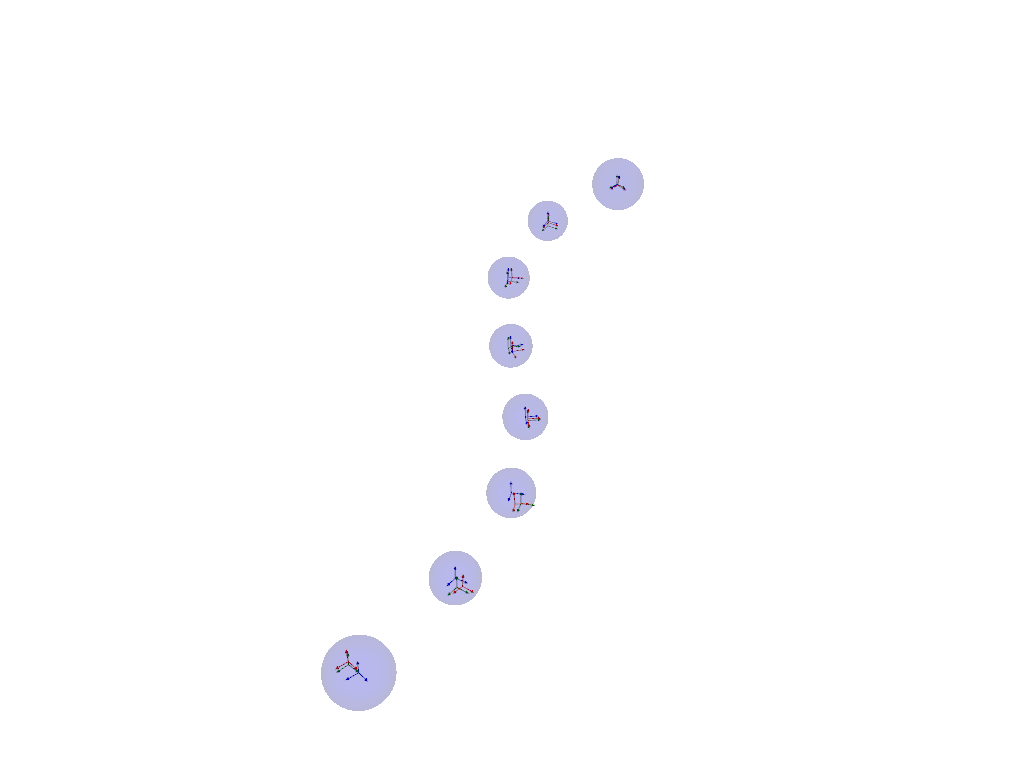

In [58]:
# Define marginal class to recover marginal covariances
marginals = gtsam.Marginals(graph, result)
# Get estimated poses, ground-truth poses and covariances
poses, poses_gt, covariances = collect_estimated_plot_data(
    result=result,
    values_gt=values_gt,
    marginals=marginals,
    est_states=est_states,
    )
# Plot the results
plot_results(
    poses=poses,
    poses_gt=poses_gt,
    covariances=covariances,
    meas_poses=meas_poses,
 )


## Sampling the Continuous Time Trajectory

As mentioned, our use of the WNOA motion prior allows us to sample the continuous-time trajectory at any time by interpolating between the estimated states. This is easily accomplished using the `updateInterpValues` function. If we want to also retrieve the covariances, we can do so with the `updateInterpValuesWithCovariance` function (these functions are futher specialized using the type suffix, `Pose3`). Again, all the relevent information required for interpolation is contained in the `StateData` objects, the factor graph and the estimated values. 

Below, we interpolate the states that are marked for interpolation in `interp_states`. We then reproduce the same plot as above with the interpolated states and their covariances.

Done interpolating!
Starting render...


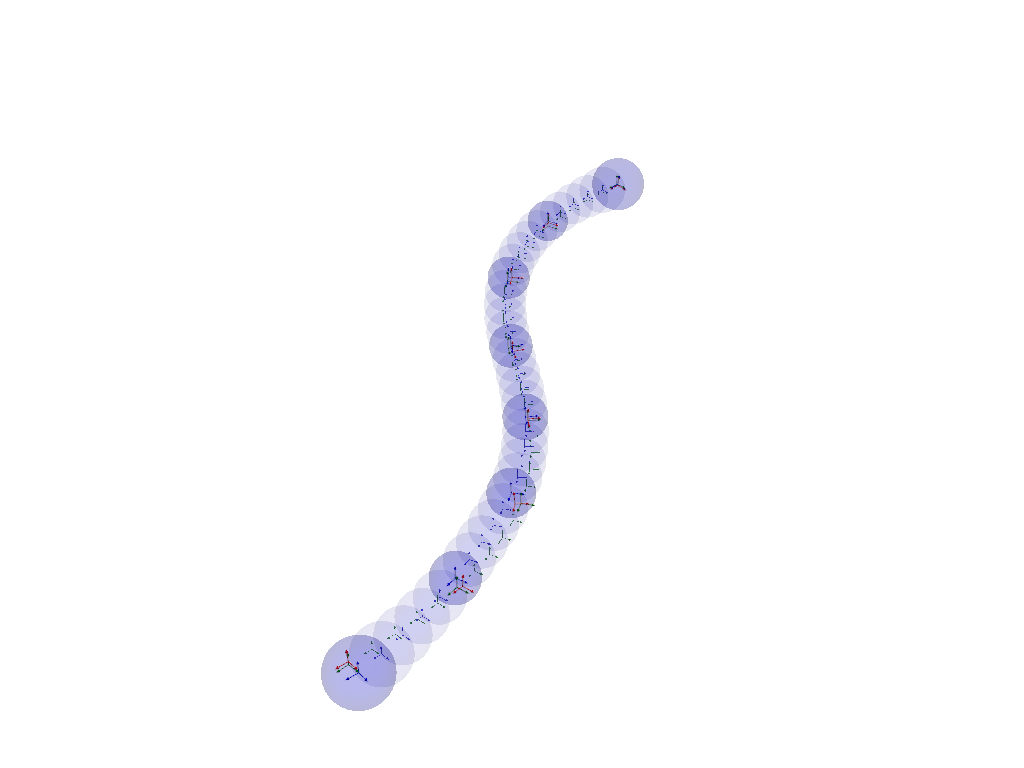

In [59]:
# Define interpolated states
interp_states: List[StateData] = []
for k in range(K_all+1):
    state_data = StateData(X(k), V(k), times_all[k])
    if not k % K_sample == 0:
        interp_states.append(state_data)

# Update the values by GP interpolation
values_interp, cov_interp = gtsam.updateInterpValuesWithCovariancePose3(
    graph, result, set(est_states), set(interp_states), Qc
    )
print("Done interpolating!")
# Gather poses for plotting
poses_int, poses_int_gt, covariances_int = collect_interp_plot_data(
    values_interp=values_interp,
    values_gt=values_gt,
    marginals=marginals,
    interp_states=interp_states,
    cov_interp=cov_interp,
    )

print("Starting render...")
plot_results(
    poses=poses,
    poses_gt=poses_gt,
    covariances=covariances,
    meas_poses=meas_poses,
    poses_int=poses_int,
    covariances_int=covariances_int,
    poses_int_gt=poses_int_gt,
    )

## Adding Measurements at Arbitrary Times

Above, we showed how to recover interpolated states *a posteriori* from the states that were directly optimized. However, one of the benefits of CT-GP estimation is that we can also include the effect of measurement factors that are defined at arbitrary times. 

We demonstrate this idea in the cell below, where we add measurement factors on interpolated states at the midpoints between the estimated states. In our GTSAM framework, we first define `StateData` objects at these arbitrary times. Internally, GP-interpolation is used to link these states to the estimated states that are directly optimized in the factor graph. 

We then create a standard GTSAM factor, treating the interpolated state keys as if they are standard variables in the factor graph. Next, we pass this factor to our `WnoaInterpFactor` wrapper factor with information that links interpolated states to the estimated states:
- `estimated_states`: the set of estimated states that border the interpolated states
- `interp_states`: the set of interpolated states that are used by the inner factor
- 'q_psd_diag': the power spectral density diagonal that defines the smoothness properties of the WNOA prior

The wrapper factor handles all of the interpolation calculations internally, inferring interpolation relationships from the inputs. The print statement below shows that the wrapped factor is a unary prior on the interpolated pose `x32`, which is mapped to the bordering state keys `x35`, `v35`, `x30`, and `v30`. Note that the wrapped factor can still be defined on non-interepolated states as well - these states are just passed through the wrapper factor without interpolation.

We also print the keys before and after adding the new factors to show that they do not change (since we are not changing the number of estimated states in the graph). 

In [60]:

graph_w_interp_meas = gtsam.NonlinearFactorGraph(graph)
for k in range(K_all+1):
    if k % K_sample == K_sample // 2:
        # Get interpolated state
        int_state = StateData(X(k), V(k), times_all[k])
        # Define unary prior on the interpolated state
        xi_pert = np.sqrt(R_meas)@np.random.randn(6,1)
        pose_meas = gtsam.Pose3.Expmap(xi_pert).compose(values_gt.atPose3(int_state.pose))       
        meas_poses.append(pose_meas) # Keep track for plotting
        # Get standard unary prior factor
        factor = gtsam.PriorFactorPose3(int_state.pose, pose_meas, noise_model)
        # Wrap with WNOA Interpolation factor
        factor_wrapped = gtsam.WnoaInterpFactorPose3(
            factor, set(est_states), set([int_state]), Qc
            )
        graph_w_interp_meas.add(factor_wrapped)

factor_wrapped.print("The wrapped factor:\n")
print("\n")
print("Keys in graph before adding new factors:")
print(", ".join([gtsam.Symbol(key).string() for key in list(graph.keys())]))
print("Keys in graph after adding new factors:")
print(", ".join([gtsam.Symbol(key).string() for key in list(graph_w_interp_meas.keys())]))


The wrapped factor:
WnoaInterpFactor on x35 v30 v35 x30 
Inner Factor: PriorFactor on x32
  prior mean:  R: [
	0.99972918, 0.0166756615, -0.0162323356;
	-0.0162613481, 0.999546883, 0.0253297631;
	0.016647371, -0.0250589436, 0.999547355
]
t:  -7.56920669  -4.24354911 0.0350191493
  noise model: diagonal sigmas [0.0316227766; 0.0316227766; 0.0316227766; 0.1; 0.1; 0.1];


Keys in graph before adding new factors:
v0, v5, v10, v15, v20, v25, v30, v35, x0, x5, x10, x15, x20, x25, x30, x35
Keys in graph after adding new factors:
v0, v5, v10, v15, v20, v25, v30, v35, x0, x5, x10, x15, x20, x25, x30, x35


Note that when we define the WNOA interpolation factor, we provided the full set of estimation states because it was convenient. However, we really only need to provide the two states that bound the state that is being interpolated (with respect to time). All interpolated states must be bounded by two states to properly define the factor.

We can now optimize the graph as before and plot our outputs.

Done interpolating!
Starting render...


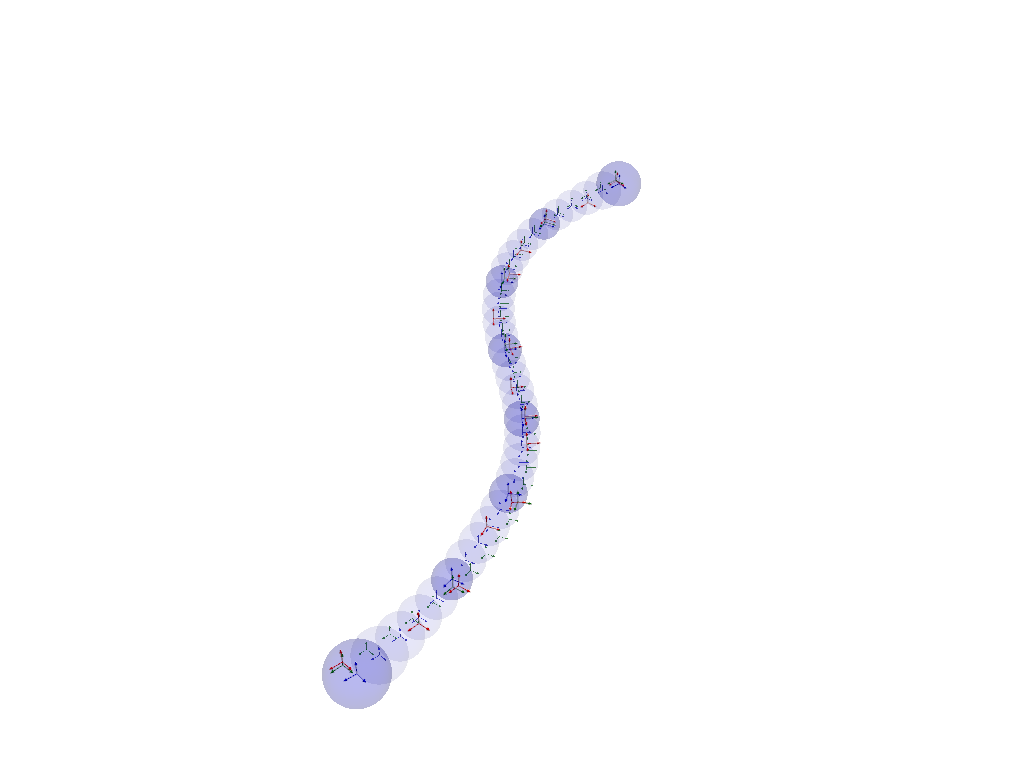

In [61]:
# Define the optimizer and optimize the graph
optimizer = gtsam.LevenbergMarquardtOptimizer(graph_w_interp_meas, values_init)
result = optimizer.optimize()

# Define marginal class to recover marginal covariances
marginals = gtsam.Marginals(graph_w_interp_meas, result)
# Update the values by GP interpolation
values_interp, cov_interp = gtsam.updateInterpValuesWithCovariancePose3(
    graph_w_interp_meas, result, set(est_states), set(interp_states), Qc
    )
print("Done interpolating!")
# Get estimated poses, ground-truth poses and covariances
poses, poses_gt, covariances = collect_estimated_plot_data(
    result=result,
    values_gt=values_gt,
    marginals=marginals,
    est_states=est_states,
    )
# Get interpolated values
poses_int, poses_int_gt, covariances_int = collect_interp_plot_data(
    values_interp=values_interp,
    values_gt=values_gt,
    marginals=marginals,
    interp_states=interp_states,
    cov_interp=cov_interp,
    )

# Generate plot
print("Starting render...")
plot_results(
    poses=poses,
    poses_gt=poses_gt,
    covariances=covariances,
    meas_poses=meas_poses,
    poses_int=poses_int,
    covariances_int=covariances_int,
    poses_int_gt=poses_int_gt,
    )

The new measurements are also shown in red in the plot and clearly occur at on the interpolated states.

# Factor Graph Interpolation Workflow

To avoid tediously wrapping all of the factors that are interpolated we have provided a convenient function, `interpolateFactorGraph` that can be used to automatically wrap factors that are defined on interpolated states. This allows the user to build a factor graph using standard workflows, then convert it to an equivalent graph that interpolates a selected set of states. This can be useful for exploring the effect of interpolating different states in the factor graph. 

We start by creating a new factor graph and adding the priors *as if we are not interpolating any states*.

To show the versatility of our approach, we randomly select whether to add measurements randomly to a given state and randomly select which states are interpolated (with only 10% of states being estimated).

In [62]:

# Create new graph
np.random.seed(10) # For reproducibility
graph = gtsam.NonlinearFactorGraph()
meas_poses = []
est_states: List[StateData] = []
interp_states: List[StateData] = []
values_init = gtsam.Values()
# Add measurement factors on estimated states and interpolated states
for k in range(K_all + 1):
    # Get the current state (either interpolated or estimated)
    curr_state = StateData(X(k), V(k), times_all[k])
    if np.random.rand() < 0.3: # Randomly add measurements to both estimated and interpolated states
        # Get measurement perturbation due to noise
        xi_pert = np.sqrt(R_meas)@np.random.randn(6,1)
        xi_pert = np.vstack([xi_pert[3:,:], xi_pert[:3,:]]) # Consistent with paper plot
        pose_pert = gtsam.Pose3.Expmap(xi_pert)
        pose_meas = pose_pert.compose(values_gt.atPose3(curr_state.pose))
        meas_poses.append(pose_meas) # Keep track for plotting
        # Add measurement
        graph.addPriorPose3(curr_state.pose, pose_meas,noise_model)
    # Randomly assign some states to estimation (including endpoints)
    if np.random.rand() < 0.1 or k == 0 or k == K_all: 
        est_states.append(curr_state)
        values_init.insert(curr_state.pose, values_gt.atPose3(curr_state.pose))
        values_init.insert(curr_state.velocity, values_gt.atVector(curr_state.velocity))
    else:
        interp_states.append(curr_state)
        
print(f"Number of estimated states: {len(est_states)}")
print(f"Number of interpolated states: {len(interp_states)}")
print(f"Number of measurement factors: {len(meas_poses)}")


Number of estimated states: 5
Number of interpolated states: 31
Number of measurement factors: 10


Note that we did not add any WNOA motion prior to the factor graph. This is because the conversion function will automatically add WNOA priors between adjacent estimated states in the graph.

Below, we convert the graph, optimize, and generate the trajectory plot, as before.

Done interpolating!
Starting render...


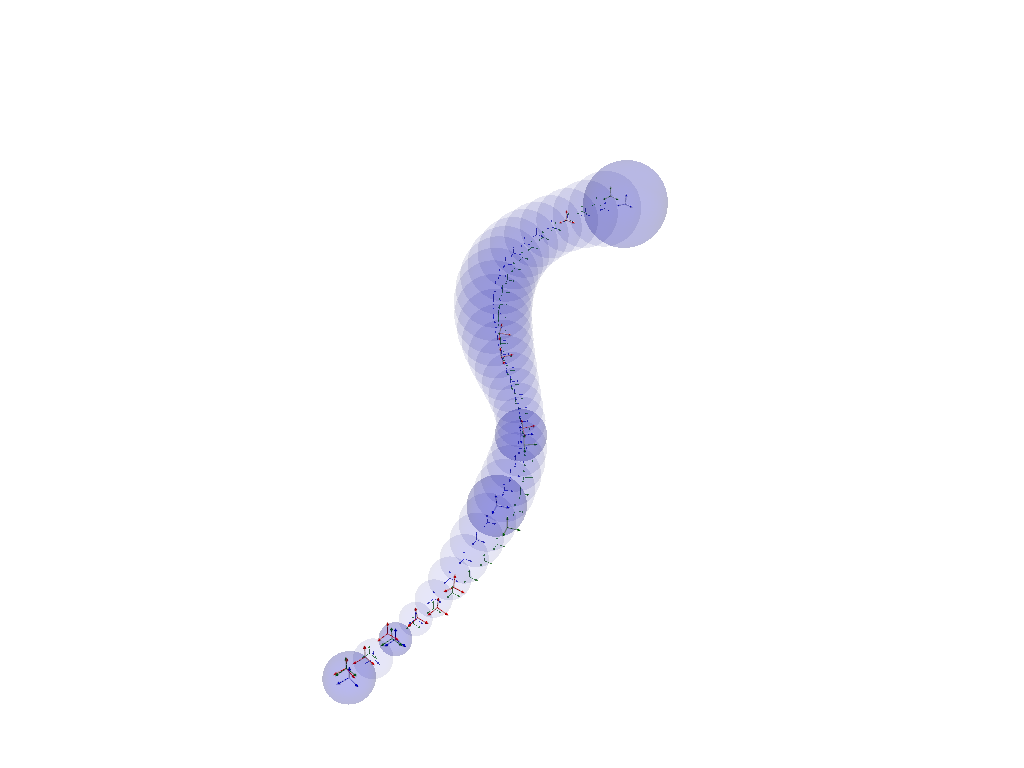

In [63]:
# Interpolate the factor graph
graph_interp = gtsam.interpolateFactorGraphPose3(
    graph, set(est_states), set(interp_states), Qc
)

# Define the optimizer and optimize the graph
optimizer = gtsam.LevenbergMarquardtOptimizer(graph_interp, values_init)
result = optimizer.optimize()

# Define marginal class to recover marginal covariances
marginals = gtsam.Marginals(graph_interp, result)
# Update the values by GP interpolation
values_interp, cov_interp = gtsam.updateInterpValuesWithCovariancePose3(
    graph_interp, result, set(est_states), set(interp_states), Qc
    )
print("Done interpolating!")
# Get estimated poses, ground-truth poses and covariances
poses, poses_gt, covariances = collect_estimated_plot_data(
    result=result,
    values_gt=values_gt,
    marginals=marginals,
    est_states=est_states,
    )
# Get interpolated values
poses_int, poses_int_gt, covariances_int = collect_interp_plot_data(
    values_interp=values_interp,
    values_gt=values_gt,
    marginals=marginals,
    interp_states=interp_states,
    cov_interp=cov_interp,
    )

# Generate plot
print("Starting render...")
plot_results(
    poses=poses,
    poses_gt=poses_gt,
    covariances=covariances,
    meas_poses=meas_poses,
    poses_int=poses_int,
    covariances_int=covariances_int,
    poses_int_gt=poses_int_gt,
    )

Note that the covariances increases in areas of the trajectory that have fewer measurements and that the trajectory and covariances are smoothly interpolated between the states.

Happy estimating (and interpolating)!